## Life Expectancy Drivers
Analyzing what predicts life expectancy across countries using World Bank data (2015-2024). Part 1 builds a regression model, part 2 looks at which countries are improving fastest over time.

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy import stats

In [2]:
# World Bank indicator codes we're pulling, with friendly column names
indicators = {
    "life_expectancy":    "SP.DYN.LE00.IN",
    "gdp_per_capita":     "NY.GDP.PCAP.CD",
    "health_spending":    "SH.XPD.CHEX.GD.ZS",
    "education_spending": "SE.XPD.TOTL.GD.ZS",
    "sanitation_access":  "SH.STA.SMSS.ZS",
    "water_access":       "SH.H2O.SMDW.ZS",
    "under5_mortality":   "SH.DYN.MORT",
}

start_year = 2015
end_year = 2024

In [3]:
# Function to fetch one indicator from the World Bank API for a range of years

def get_indicator_range(code, start_year, end_year):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}"
    params = {"date": f"{start_year}:{end_year}", "format": "json", "per_page": 20000}

    response = requests.get(url, params=params)
    data = response.json()

    # checking the response is shaped how we expect before parsing
    if len(data) < 2:
        print("Problem with code:", code)
        print(data)
        return pd.DataFrame()

    records = data[1]
    rows = []
    for r in records:
        rows.append({
            "country_code": r["countryiso3code"],
            "country": r["country"]["value"],
            "year": int(r["date"]),
            "value": r["value"],
        })

    return pd.DataFrame(rows)

In [4]:
# Fetching all indicators and keeping each country's most recent available value

def data_load():
    all_data = {}
    for name, code in indicators.items():
        df = get_indicator_range(code, start_year, end_year)

        if df.empty:
            print("Skipping", name, "-- no data returned")
            continue

        df = df.dropna(subset=["value"])
        df = df.sort_values("year", ascending=False)
        df = df.drop_duplicates(subset="country_code", keep="first")
        all_data[name] = df
        print(name, ":", df["country_code"].nunique(), "countries")

    return all_data

all_data = data_load()

life_expectancy : 261 countries
gdp_per_capita : 257 countries
health_spending : 237 countries
education_spending : 233 countries
sanitation_access : 173 countries
water_access : 176 countries
under5_mortality : 240 countries


In [5]:
# Merging all indicators into one table, matched on country_code

merged = all_data["life_expectancy"][["country_code", "country", "value"]].copy()
merged = merged.rename(columns={"value": "life_expectancy"})

for name in indicators:
    if name == "life_expectancy":
        continue
    temp = all_data[name][["country_code", "value"]].rename(columns={"value": name})
    merged = merged.merge(temp, on="country_code", how="left")

merged.head(10)

,country_code,country,life_expectancy,gdp_per_capita,health_spending,education_spending,sanitation_access,water_access,under5_mortality
0,AUT,Austria,81.995122,58268.878765,11.832563,5.277490,98.502318,98.891536,3.3
1,AZE,Azerbaijan,74.576000,7294.642761,4.271135,3.660360,68.003345,57.811828,17.9
2,BHS,"Bahamas, The",74.710000,39455.446655,6.302608,2.741916,NaN,NaN,12.4
3,BHR,Bahrain,81.423000,29717.142461,3.995624,1.887782,93.352599,98.903976,8.8
4,BGD,Bangladesh,74.930000,2593.416117,2.170146,2.034385,37.320498,59.125426,30.5
5,BRB,Barbados,76.332000,26897.200204,5.404638,3.555932,NaN,NaN,9.8
6,AGO,Angola,64.805000,2720.819007,2.546929,2.512737,NaN,NaN,49.0
7,BLR,Belarus,74.365341,8605.609546,7.081674,5.045940,74.437110,93.059755,2.3
8,UKR,Ukraine,74.692000,5391.622559,8.202748,5.140100,92.393890,87.868377,7.9
9,ARE,United Arab Emirates,83.069000,50273.512624,4.970951,3.894040,98.449700,98.641317,4.8


In [6]:
# The "all countries" list includes regional/income group aggregates, not real countries
non_countries = [
    "World", "High income", "Low income", "Middle income",
    "Upper middle income", "Lower middle income", "OECD members",
    "Euro area", "European Union", "Arab World", "East Asia & Pacific",
    "Europe & Central Asia", "Latin America & Caribbean",
    "Middle East & North Africa", "North America", "South Asia",
    "Sub-Saharan Africa", "IDA & IBRD total", "Low & middle income",
    "Fragile and conflict affected situations",
    "Heavily indebted poor countries (HIPC)",
    "Least developed countries: UN classification",
]

merged = merged[~merged["country"].isin(non_countries)]

print("Rows before dropping missing values:", len(merged))
clean = merged.dropna()
print("Rows after dropping missing values:", len(clean))
clean.head()

Rows before dropping missing values: 244
Rows after dropping missing values: 129


,country_code,country,life_expectancy,gdp_per_capita,health_spending,education_spending,sanitation_access,water_access,under5_mortality
0,AUT,Austria,81.995122,58268.878765,11.832563,5.277490,98.502318,98.891536,3.3
1,AZE,Azerbaijan,74.576000,7294.642761,4.271135,3.660360,68.003345,57.811828,17.9
3,BHR,Bahrain,81.423000,29717.142461,3.995624,1.887782,93.352599,98.903976,8.8
4,BGD,Bangladesh,74.930000,2593.416117,2.170146,2.034385,37.320498,59.125426,30.5
7,BLR,Belarus,74.365341,8605.609546,7.081674,5.045940,74.437110,93.059755,2.3


In [7]:
# GDP and under-5 mortality are both heavily skewed, log-transforming both before modeling
clean = clean.copy()
clean["log_gdp_per_capita"] = np.log(clean["gdp_per_capita"])
clean["log_under5_mortality"] = np.log(clean["under5_mortality"])

clean[["gdp_per_capita", "log_gdp_per_capita", "under5_mortality", "log_under5_mortality"]].head()

,gdp_per_capita,log_gdp_per_capita,under5_mortality,log_under5_mortality
0,58268.878765,10.972823,3.3,1.193922
1,7294.642761,8.894895,17.9,2.884801
3,29717.142461,10.299479,8.8,2.174752
4,2593.416117,7.860731,30.5,3.417727
7,8605.609546,9.060170,2.3,0.832909


In [12]:
clean.describe()

,life_expectancy,gdp_per_capita,health_spending,education_spending,sanitation_access,water_access,under5_mortality,log_gdp_per_capita,log_under5_mortality
count,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000
mean,74.150821,22778.361651,7.060140,4.287853,61.065356,67.470299,23.516585,9.061374,2.557229
std,7.554875,35563.708169,3.477672,1.950393,29.162151,30.023594,25.363010,1.501456,1.150116
min,54.635000,416.871146,1.326516,0.319069,8.051033,6.217488,1.300000,6.032777,0.262364
25%,68.487000,2593.416117,4.561095,3.229743,33.155693,41.235296,4.700000,7.860731,1.547563
50%,74.965456,8526.296657,6.781033,4.059880,62.174362,74.967263,13.400000,9.050910,2.595255
75%,81.359000,31428.354782,8.507103,5.261660,90.192500,96.890323,36.400000,10.355466,3.594569
max,86.497000,288001.574856,27.089685,16.390530,100.000000,100.000000,115.600000,12.570721,4.750136


In [11]:
# Checking a couple of extreme values flagged in describe()
clean.sort_values("gdp_per_capita", ascending=False).head(3)[["country", "gdp_per_capita"]]
clean.sort_values("health_spending", ascending=False).head(3)[["country", "health_spending"]]

,country,health_spending
30,Tuvalu,27.089685
189,Naoero,18.210760
11,United States,16.694149


#### Exploring the data

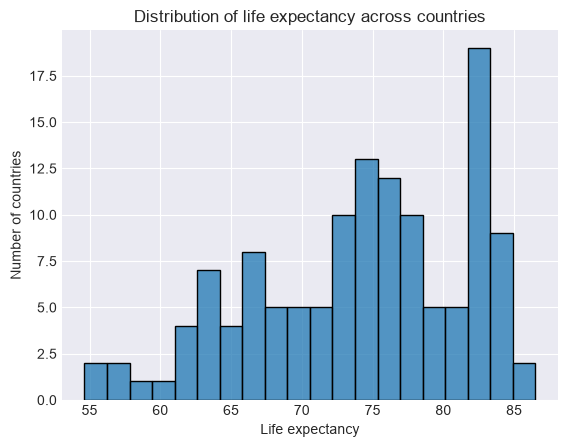

In [13]:
plt.style.use('seaborn-v0_8-darkgrid')

sns.histplot(clean["life_expectancy"], bins=20)
plt.xlabel("Life expectancy")
plt.ylabel("Number of countries")
plt.title("Distribution of life expectancy across countries")
plt.show()

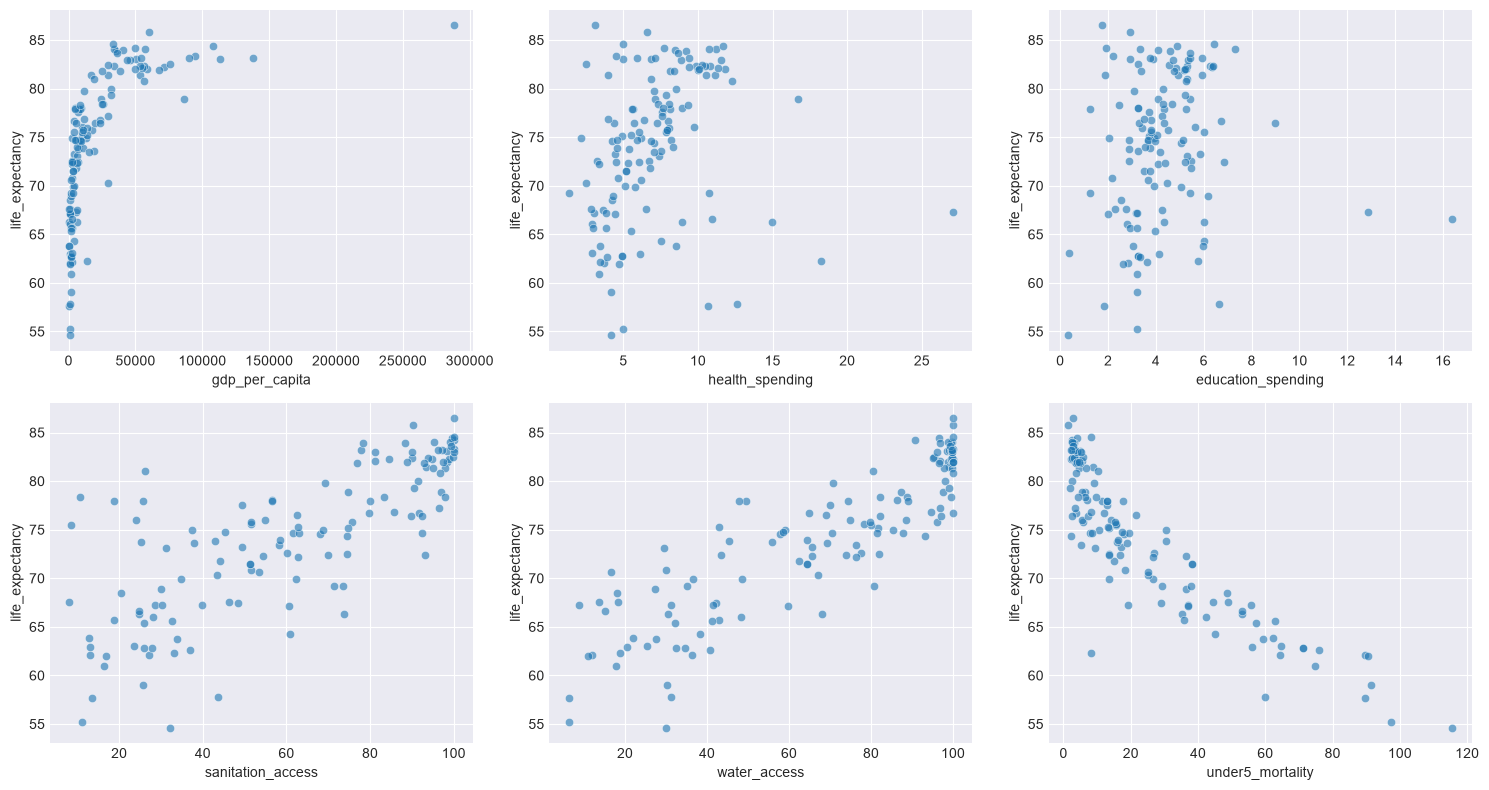

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

pairs = [
    ("gdp_per_capita", axes[0, 0]),
    ("health_spending", axes[0, 1]),
    ("education_spending", axes[0, 2]),
    ("sanitation_access", axes[1, 0]),
    ("water_access", axes[1, 1]),
    ("under5_mortality", axes[1, 2]),
]

for column, ax in pairs:
    sns.scatterplot(data=clean, x=column, y="life_expectancy", ax=ax, alpha=0.6)

plt.tight_layout()
plt.show()

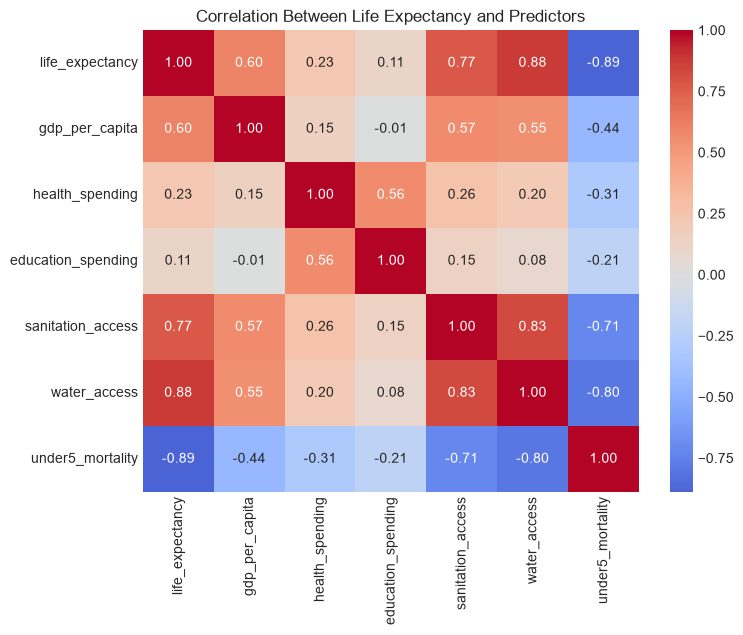

In [15]:
plt.figure(figsize=(8, 6))
corr = clean[["life_expectancy", "gdp_per_capita", "health_spending",
              "education_spending", "sanitation_access", "water_access",
              "under5_mortality"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Between Life Expectancy and Predictors")
plt.show()

Sanitation, water access, and under-5 mortality are all fairly correlated with each other (0.7-0.88), which likely means the regression will struggle to fully separate their individual effects. Worth checking with VIF later.

### Regression

In [16]:
feature_columns = [
    "log_gdp_per_capita",
    "health_spending",
    "education_spending",
    "sanitation_access",
    "water_access",
    "log_under5_mortality",
]

X = clean[feature_columns]
y = clean["life_expectancy"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     135.8
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           1.49e-51
Time:                        22:50:27   Log-Likelihood:                -311.94
No. Observations:                 129   AIC:                             637.9
Df Residuals:                     122   BIC:                             657.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   68.0948 

R² of 0.87, the six variables explain most of the variation in life expectancy across these 129 countries. Under-5 mortality dominates the effect size, which isn't too surprising since it's close to definitionally tied to how life expectancy gets calculated. Health spending came out negative, more likely reverse causality (countries with worse outcomes spend more reactively) than a real effect.

In [17]:
# Standardizing so coefficients are comparable across variables measured in different units
X_features = clean[feature_columns]
X_standardized = (X_features - X_features.mean()) / X_features.std()
y_standardized = (clean["life_expectancy"] - clean["life_expectancy"].mean()) / clean["life_expectancy"].std()

X_standardized = sm.add_constant(X_standardized)
model_standardized = sm.OLS(y_standardized, X_standardized).fit()

importance = model_standardized.params.drop("const").sort_values(key=abs, ascending=False)
print(importance)

log_under5_mortality   -0.480389
water_access            0.340012
log_gdp_per_capita      0.216118
health_spending        -0.097679
sanitation_access      -0.045344
education_spending      0.043032
dtype: float64


Under-5 mortality and water access are the two strongest predictors once everything's on the same scale, both bigger than GDP. Sanitation and education spending drop out almost completely, probably because their signal overlaps with water access and mortality.

### Multicollinearity (VIF)

In [18]:
X_with_const = sm.add_constant(clean[feature_columns])

vif_data = pd.DataFrame()
vif_data["variable"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]
vif_data = vif_data[vif_data["variable"] != "const"]

vif_data.sort_values("VIF", ascending=False)

,variable,VIF
6,log_under5_mortality,6.951189
1,log_gdp_per_capita,6.240205
5,water_access,5.422681
4,sanitation_access,3.656554
2,health_spending,1.718531
3,education_spending,1.487027


Under-5 mortality, GDP, and water access all sit around 5.4-7.0, moderate multicollinearity. Not severe enough to throw the regression out, but enough that these three should be read as a cluster of related development signals rather than fully separate effects.

#### Train/test validation

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    clean[feature_columns], clean["life_expectancy"], test_size=0.2, random_state=42
)

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

train_model = sm.OLS(y_train, X_train_const).fit()
predictions = train_model.predict(X_test_const)
test_r2 = r2_score(y_test, predictions)

print("R-squared on training data:", round(train_model.rsquared, 3))
print("R-squared on unseen test data:", round(test_r2, 3))

R-squared on training data: 0.886
R-squared on unseen test data: 0.804


R² held up reasonably well on the held-out 20% (0.80 vs 0.89 on training), suggesting the model isn't just memorizing quirks of these 129 countries. Test set is only 26 countries though, so this single split shouldn't be read as a precise number, cross-validation would give a steadier read.

#### Residual diagnostics

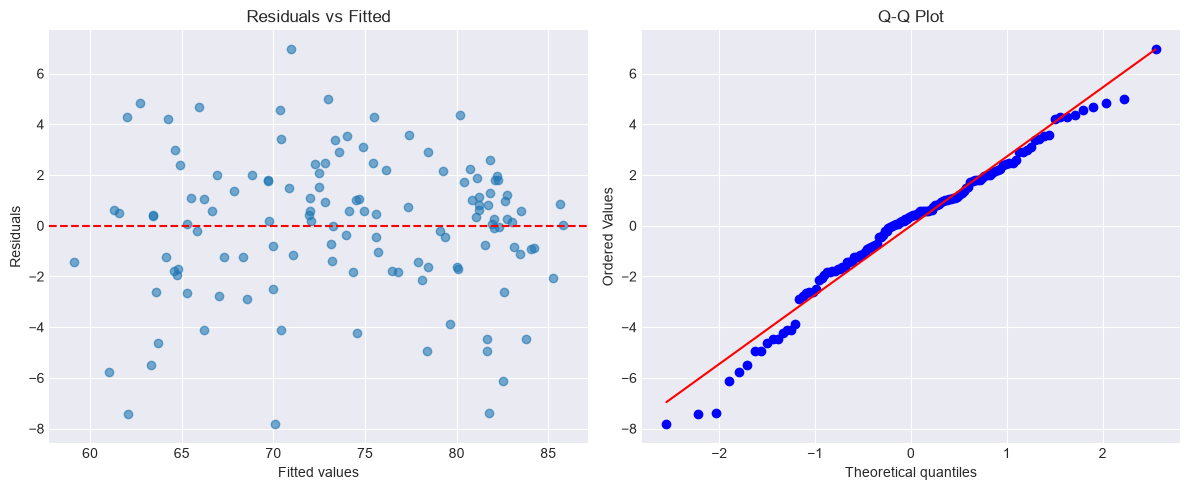

In [20]:
fitted_values = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(fitted_values, residuals, alpha=0.6)
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

Residuals vs fitted look reasonably random, no obvious pattern. The Q-Q plot shows heavier tails than a normal distribution though, especially at both ends, meaning the p-values and confidence intervals above are approximate rather than exact, and the model is least reliable at the extremes of the life expectancy range.

In [21]:
clean["residual"] = model.resid

# Countries the model most underpredicts
clean.sort_values("residual", ascending=False).head(5)[["country", "life_expectancy", "residual"]]

,country,life_expectancy,residual
241,Lebanon,77.945,6.958473
137,Peru,77.941,4.977994
237,Malawi,67.561,4.843629
190,Nepal,70.636,4.696529
4,Bangladesh,74.930,4.573183


In [22]:
# Countries the model most overpredicts
clean.sort_values("residual").head(5)[["country", "life_expectancy", "residual"]]

,country,life_expectancy,residual
189,Naoero,62.279000,-7.829116
172,Nigeria,54.635000,-7.414146
7,Belarus,74.365341,-7.379477
240,Latvia,76.429268,-6.111328
65,Chad,55.238000,-5.787306


Lebanon, Peru, Malawi, Nepal, and Bangladesh all do noticeably better on life expectancy than their GDP, spending, and infrastructure numbers alone predict, several are known for strong primary healthcare systems relative to income.

The countries the model most overpredicts split into two different stories. Nigeria and Chad already have low life expectancy and still do worse than their numbers suggest, likely conflict and health-system disruption not captured by any of these indicators. Belarus and Latvia are closer to the opposite case, decent income and infrastructure but life expectancy well below what that would normally predict, which lines up with the well-documented Eastern European mortality pattern driven by alcohol, smoking, and cardiovascular disease rather than a resource gap.

### Improvement over time

which countries are gaining the fastest, and where that trend might be headed if it keeps up.

In [23]:
# Getting life expectancy history for every country, not just the latest value this time
life_exp_history = get_indicator_range("SP.DYN.LE00.IN", start_year, end_year)
life_exp_history = life_exp_history[~life_exp_history["country"].isin(non_countries)]
life_exp_history = life_exp_history.dropna(subset=["value"])

# only keeping countries with enough years of data to fit a trend on
counts = life_exp_history.groupby("country_code").size()
enough_data = counts[counts >= 5].index
life_exp_history = life_exp_history[life_exp_history["country_code"].isin(enough_data)]

print("Countries with enough history:", life_exp_history["country_code"].nunique())
life_exp_history.head()

Countries with enough history: 244


,country_code,country,year,value
0,AFE,Africa Eastern and Southern,2024,65.349930
1,AFE,Africa Eastern and Southern,2023,65.146228
2,AFE,Africa Eastern and Southern,2022,64.487152
3,AFE,Africa Eastern and Southern,2021,62.979999
4,AFE,Africa Eastern and Southern,2020,63.766484
